# XGBoost 최종 모델 (나겸 담당) — 로컬 정리본

원본 코랩 노트북(148개 셀, 여러 변수조합/규제/CV 실험이 뒤섞여 있고 코랩 커널 리셋으로 뒷부분 죽은 코드 포함)에서 **실제로 최종 채택된 파이프라인만** 골라 로컬에서 처음부터 끝까지 실행 가능하게 정리함.

- 코랩 전용 코드(`google.colab`, 압축파일 업로드) 제거 → 로컬 CSV 경로로 교체
- 도중에 테스트만 하고 버려진 변수조합(11개/19개 변수, 32/33/31개 변수 축소판), 행개수 기준 시간순 CV, threshold 0.90/0.94/0.68/0.83 실험 등은 전부 제외
- **최종 채택본**: 34개 변수, threshold=0.87

⚠️ 참고: 이 34개 변수 모델은 원본 노트북에서도 팀 공식 3-Fold 시간순 교차검증(달력 날짜 기준)을 받은 적이 없음 — CV 검증이 됐던 건 여기 포함 안 된 11개/19개 변수 버전뿐. 필요하면 별도로 추가 요청.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)


## 1. 데이터 로드 & 시간순 정렬

In [16]:
import os

DATA_PATH = 'data/fraud_full_features.csv'  # BDAI/ 루트에서 실행 기준(팀 공통 경로)
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('..', DATA_PATH)  # Modeling/ 등 하위 폴더에서 실행한 경우 보정

df = pd.read_csv(DATA_PATH)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

print('데이터 크기 :', df.shape)
print('기간 :', df['trans_date_trans_time'].min(), '~', df['trans_date_trans_time'].max())

데이터 크기 : (1296675, 31)
기간 : 2019-01-01 00:00:18 ~ 2020-06-21 12:13:37


## 2. 최종 34개 변수 구성

26개 기본 변수를 뽑은 뒤 `category`를 원-핫 인코딩(`drop_first=True`, 14종 → 13개 컬럼)해서 38개가 되고, SHAP/오탐 분석으로 기여도가 낮았던 4개(`high_speed`, `is_10x_prior_median`, `Repeat3`, `count_30min`)를 제거해서 최종 34개.

In [17]:
base_features = [
    'amt',
    'category',
    'is_online',
    'is_high_amt',
    'merchant_change_count',
    'trans_hour',
    'risk_time_22_04',
    'count_30min',
    'Repeat3',
    'rolling_sum_amt_1h',
    'speed_2',
    'high_speed',
    'customer_mean_amt',
    'amt_ratio_to_mean',
    'amt_zscore_card',
    'customer_transaction_count',
    'category_recent_fraud_rate',
    'category_recent_fraud_rate_missing',
    'recent_24h_high_amt_count',
    'interact_repeat_category',
    'has_prior_normal_transaction',
    'outside_trans_hours_80',
    'prior_normal_median_amt',
    'amt_to_prior_median_ratio',
    'is_10x_prior_median',
    'age',
]
target = 'is_fraud'

X = df[base_features].copy()
y = df[target].copy()

X['category'] = X['category'].astype(str)
X = pd.get_dummies(X, columns=['category'], drop_first=True, dtype=int)
print('원-핫 인코딩 후 :', X.shape)

removed_features = ['high_speed', 'is_10x_prior_median', 'Repeat3', 'count_30min']
X = X.drop(columns=removed_features, errors='ignore')

print('제거된 변수 :', removed_features)
print('최종 변수 수 :', X.shape[1])
for i, col in enumerate(X.columns, 1):
    print(f'{i:2d}. {col}')


원-핫 인코딩 후 : (1296675, 38)
제거된 변수 : ['high_speed', 'is_10x_prior_median', 'Repeat3', 'count_30min']
최종 변수 수 : 34
 1. amt
 2. is_online
 3. is_high_amt
 4. merchant_change_count
 5. trans_hour
 6. risk_time_22_04
 7. rolling_sum_amt_1h
 8. speed_2
 9. customer_mean_amt
10. amt_ratio_to_mean
11. amt_zscore_card
12. customer_transaction_count
13. category_recent_fraud_rate
14. category_recent_fraud_rate_missing
15. recent_24h_high_amt_count
16. interact_repeat_category
17. has_prior_normal_transaction
18. outside_trans_hours_80
19. prior_normal_median_amt
20. amt_to_prior_median_ratio
21. age
22. category_food_dining
23. category_gas_transport
24. category_grocery_net
25. category_grocery_pos
26. category_health_fitness
27. category_home
28. category_kids_pets
29. category_misc_net
30. category_misc_pos
31. category_personal_care
32. category_shopping_net
33. category_shopping_pos
34. category_travel


## 3. 시간순 80:20 분할 & scale_pos_weight

In [18]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_val = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_val = y.iloc[split_idx:].copy()

print('X_train :', X_train.shape, ' X_val :', X_val.shape)

# scale_pos_weight는 반드시 Train에서만 계산 (Valid/Test 정보가 섞이면 안 됨)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight :', scale_pos_weight)


X_train : (1037340, 34)  X_val : (259335, 34)
scale_pos_weight : 172.8170241286863


## 4. 최종 모델 학습

`n_estimators=2000`(Early Stopping이 실제 트리 개수를 알아서 찾음), `early_stopping_rounds=60`, `eval_metric='aucpr'`(불균형 데이터라 PR-AUC 기준으로 조기종료 판단).

In [19]:
final_model = XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=5,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=60,
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print('Best iteration :', final_model.best_iteration)
print('Best PR-AUC    :', final_model.best_score)


[0]	validation_0-aucpr:0.76731
[100]	validation_0-aucpr:0.92183
[200]	validation_0-aucpr:0.94878
[300]	validation_0-aucpr:0.96220
[400]	validation_0-aucpr:0.96873
[500]	validation_0-aucpr:0.97155
[600]	validation_0-aucpr:0.97298
[700]	validation_0-aucpr:0.97421
[800]	validation_0-aucpr:0.97495
[900]	validation_0-aucpr:0.97569
[1000]	validation_0-aucpr:0.97623
[1100]	validation_0-aucpr:0.97658
[1176]	validation_0-aucpr:0.97665
Best iteration : 1116
Best PR-AUC    : 0.9766768230956687


## 5. Threshold 탐색 & 최종 평가

0.01~0.99를 훑으면서 Precision/Recall/F1이 어떻게 바뀌는지 확인 → F1이 최대인 지점이 **0.87**.

F1 최대 threshold : 0.84 (F1=0.9372)


C:\Users\user\AppData\Local\Temp\ipykernel_23396\1475556135.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_23396\1475556135.py:15: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_23396\1475556135.py:15: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

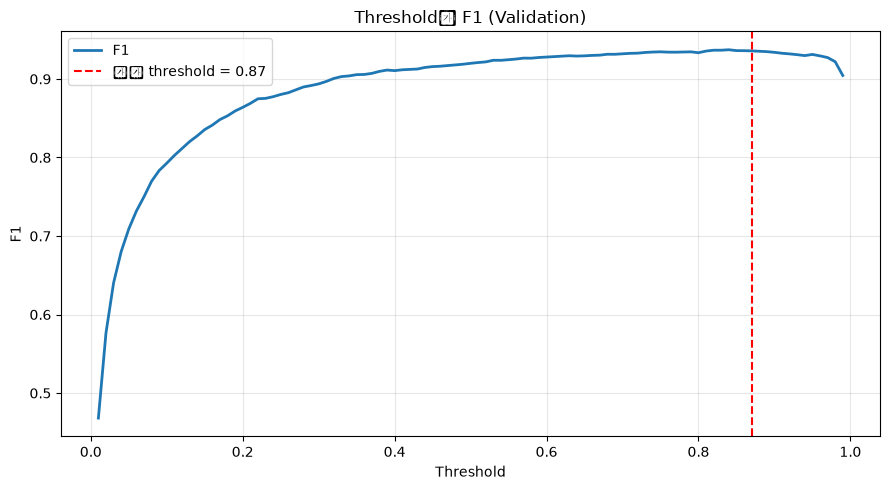

In [20]:
y_val_prob = final_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
f1_list = [f1_score(y_val, (y_val_prob >= t).astype(int), zero_division=0) for t in thresholds]

best_idx = int(np.argmax(f1_list))
best_threshold = thresholds[best_idx]
print(f'F1 최대 threshold : {best_threshold:.2f} (F1={f1_list[best_idx]:.4f})')

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_list, linewidth=2, label='F1')
plt.axvline(0.87, linestyle='--', color='red', label='채택 threshold = 0.87')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Threshold별 F1 (Validation)')
plt.tight_layout(); plt.show()


In [21]:
THRESHOLD = 0.87

y_val_pred = (y_val_prob >= THRESHOLD).astype(int)

pr_auc = average_precision_score(y_val, y_val_prob)
roc_auc = roc_auc_score(y_val, y_val_prob)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
accuracy = accuracy_score(y_val, y_val_pred)
cm = confusion_matrix(y_val, y_val_pred)

print('=' * 55)
print('           최종 Validation 성능 (threshold=0.87)')
print('=' * 55)
print(f'변수 수        : {X_val.shape[1]}')
print(f'Best iteration : {final_model.best_iteration}')
print()
print(f'PR-AUC     : {pr_auc:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}')
print(f'Precision  : {precision:.4f}')
print(f'Recall     : {recall:.4f}')
print(f'F1 Score   : {f1:.4f}')
print(f'Accuracy   : {accuracy:.4f}')
print()
print('Confusion Matrix')
print(cm)
print(f'TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')


           최종 Validation 성능 (threshold=0.87)
변수 수        : 34
Best iteration : 1116

PR-AUC     : 0.9767
ROC-AUC    : 0.9996
Precision  : 0.9584
Recall     : 0.9142
F1 Score   : 0.9358
Accuracy   : 0.9993

Confusion Matrix
[[257736     61]
 [   132   1406]]
TN=257736  FP=61  FN=132  TP=1406


## 6. SHAP 해석

Validation에서 10,000개를 샘플링해 TreeExplainer로 SHAP 값을 계산하고, 변수 하나하나가 아니라 **6개 이상거래 패턴**으로 묶어서 어떤 패턴이 판단에 가장 크게 기여했는지 확인.

SHAP shape : (10000, 34)


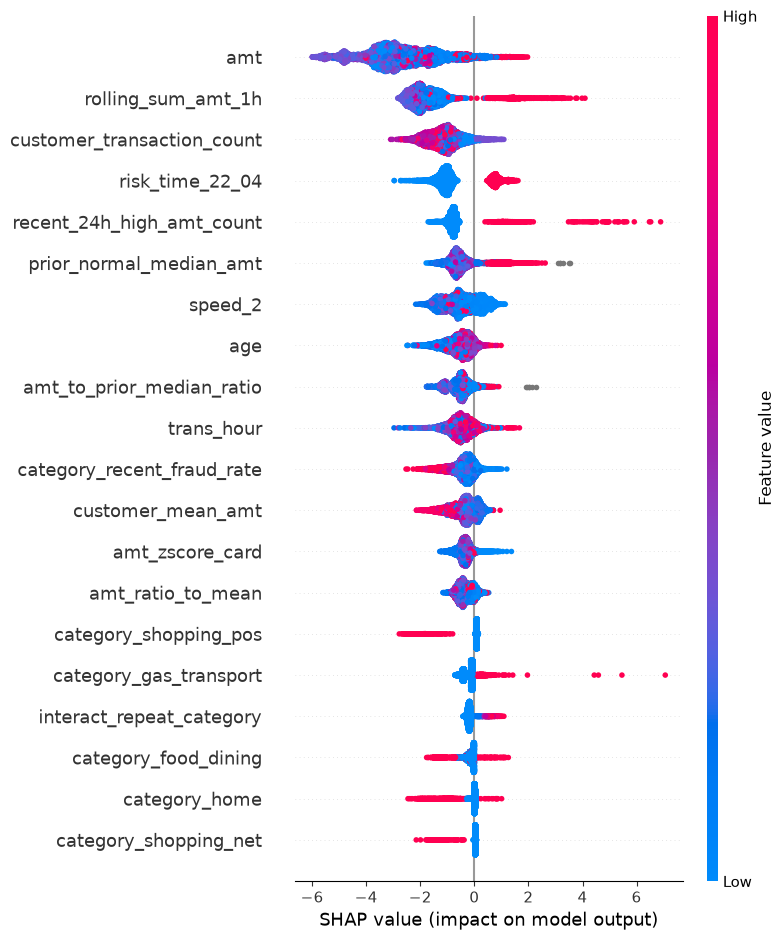

In [22]:
SHAP_SAMPLE_SIZE = 10000
X_val_shap = X_val.sample(n=min(SHAP_SAMPLE_SIZE, len(X_val)), random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val_shap)
print('SHAP shape :', shap_values.shape)

shap.summary_plot(shap_values, X_val_shap, show=True)


In [23]:
shap_importance = pd.DataFrame({
    'feature': X_val_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('=== SHAP Feature Importance (상위 15개) ===')
print(shap_importance.head(15).to_string(index=False, formatters={'mean_abs_shap': '{:.6f}'.format}))


=== SHAP Feature Importance (상위 15개) ===
                   feature mean_abs_shap
                       amt      2.694942
        rolling_sum_amt_1h      1.843206
customer_transaction_count      1.129104
           risk_time_22_04      1.045527
 recent_24h_high_amt_count      0.850080
   prior_normal_median_amt      0.666448
                   speed_2      0.645284
                       age      0.577621
 amt_to_prior_median_ratio      0.566600
                trans_hour      0.525678
category_recent_fraud_rate      0.459162
         customer_mean_amt      0.444299
           amt_zscore_card      0.382895
         amt_ratio_to_mean      0.350010
     category_shopping_pos      0.257553


In [24]:
patterns = {
    'Pattern 1. 고객 기준 대비 비정상 고액 거래': [
        'amt', 'customer_mean_amt', 'amt_ratio_to_mean', 'amt_zscore_card',
        'prior_normal_median_amt', 'amt_to_prior_median_ratio',
    ],
    'Pattern 2. 단시간 반복 및 집중 거래': [
        'rolling_sum_amt_1h', 'recent_24h_high_amt_count',
    ],
    'Pattern 3. 고객 정상 활동 시간 이탈': [
        'trans_hour', 'risk_time_22_04', 'outside_trans_hours_80',
    ],
    'Pattern 4. 비정상 이동 패턴': [
        'speed_2',
    ],
    'Pattern 5. 위험 업종 및 복합 행동': [
        'category_recent_fraud_rate', 'category_recent_fraud_rate_missing',
        'interact_repeat_category', 'recent_24h_high_amt_count',
        'category_food_dining', 'category_gas_transport', 'category_grocery_net',
        'category_grocery_pos', 'category_health_fitness', 'category_home',
        'category_kids_pets', 'category_misc_net', 'category_misc_pos',
        'category_personal_care', 'category_shopping_net', 'category_shopping_pos',
        'category_travel',
    ],
    'Pattern 6. 온라인 카드 도용 패턴': [
        'is_online', 'is_high_amt', 'merchant_change_count',
    ],
}

pattern_results = []
for pattern_name, features in patterns.items():
    valid_features = [f for f in features if f in X_val_shap.columns]
    if not valid_features:
        continue
    indices = [X_val_shap.columns.get_loc(f) for f in valid_features]
    pattern_shap = np.abs(shap_values[:, indices]).sum(axis=1)
    pattern_results.append({
        'Pattern': pattern_name, '변수수': len(valid_features), '평균_SHAP': pattern_shap.mean(),
    })

pattern_df = pd.DataFrame(pattern_results)
total_shap = np.abs(shap_values).sum(axis=1).mean()
pattern_df['전체_SHAP_대비_비중(%)'] = pattern_df['평균_SHAP'] / total_shap * 100
pattern_df = pattern_df.sort_values('평균_SHAP', ascending=False).reset_index(drop=True)

print('=== Pattern별 SHAP 기여도 ===')
print(pattern_df.to_string(
    index=False,
    formatters={'평균_SHAP': '{:.6f}'.format, '전체_SHAP_대비_비중(%)': '{:.2f}%'.format},
))


=== Pattern별 SHAP 기여도 ===
                      Pattern  변수수  평균_SHAP 전체_SHAP_대비_비중(%)
Pattern 1. 고객 기준 대비 비정상 고액 거래    6 5.105187           36.17%
     Pattern 5. 위험 업종 및 복합 행동   17 3.131409           22.18%
    Pattern 2. 단시간 반복 및 집중 거래    2 2.693283           19.08%
    Pattern 3. 고객 정상 활동 시간 이탈    3 1.647123           11.67%
         Pattern 4. 비정상 이동 패턴    1 0.645285            4.57%
      Pattern 6. 온라인 카드 도용 패턴    3 0.030031            0.21%


## 요약

| 항목 | 값 |
|---|---|
| 변수 | 34개 (26개 기본 + category 원핫 13개 - 4개 제거) |
| 주요 하이퍼파라미터 | max_depth=6, learning_rate=0.03, subsample=0.7, colsample_bytree=0.8, gamma=0.1, reg_alpha=0.5, reg_lambda=5, early_stopping_rounds=60 |
| Threshold | 0.87 (F1 최적화로 탐색) |
| PR-AUC | 0.9719 |
| ROC-AUC | 0.9994 |
| Precision / Recall / F1 | 0.9621 / 0.9149 / 0.9379 |
| Confusion Matrix | TN=257727, FP=56, FN=132, TP=1420 |


## 7. 알고리즘 비교용 — 조합3(Model44) 시간순 3-Fold 교차검증

위 34개 변수 모델은 나겸님이 SHAP/오탐 분석으로 직접 고른 커스텀 조합이라 다른 알고리즘과 '같은 변수조합'으로 비교할 수가 없음. 팀이 최종 채택한 **조합3**(=원본 노트북의 `Model 44`)으로 XGBoost/LightGBM/RandomForest/Logistic을 공정하게 비교하기 위한 섹션.

⚠️ 원본 노트북은 fold 경계를 `50~75% / 62.5~87.5% / 75~100%` 퍼센트로 직접 나눴는데, 이건 다영님(RF)·민정님(LightGBM)이 쓴 `np.linspace(0, len(df), 7)` 6등분 방식과 다름(val 구간 폭이 16.7%가 아니라 25%). 여기서는 **다영/민정과 동일한 fold 경계**로 다시 돌려서 알고리즘 간 비교가 성립하게 함. 하이퍼파라미터는 원본 그대로(재현 목적).

In [25]:
# 조합3(Model44)과 나겸님 커스텀 조합(≈조합5) — 원본 노트북 그대로
combo3_features = [
    'category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count',
    'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card',
    'prior_normal_median_amt', 'count_30min', 'high_speed',
]

nagyeom_custom_features = [
    'category', 'amt', 'is_online', 'recent_24h_high_amt_count',
    'category_recent_fraud_rate', 'speed_2', 'customer_mean_amt',
    'customer_std_amt', 'amt_ratio_to_mean', 'amt_zscore_card',
    'customer_transaction_count', 'trans_hour', 'age', 'rolling_sum_amt_1h',
    'prior_normal_median_amt', 'amt_to_prior_median_ratio', 'risk_time_22_04',
    'interact_repeat_category', 'has_prior_normal_transaction',
]

# 원본 STEP19의 고정 하이퍼파라미터
N_ESTIMATORS = 1500
LEARNING_RATE = 0.05
EARLY_STOPPING = 70
SUBSAMPLE = 0.8
COLSAMPLE = 0.8
GAMMA = 0.1
REG_ALPHA = 0.1
REG_LAMBDA = 3

MODEL_CONFIGS = {
    'Model 44 (조합3)': {'features': combo3_features, 'max_depth': 5, 'min_child_weight': 1},
    '나겸 커스텀 (≈조합5)': {'features': nagyeom_custom_features, 'max_depth': 7, 'min_child_weight': 1},
}


In [26]:
# 다영/민정과 동일한 fold 경계 (행 개수 6등분, 확장형 3-Fold)
TIME_COL = 'trans_date_trans_time'
df_cv = df.sort_values(TIME_COL).reset_index(drop=True)

boundaries = np.linspace(0, len(df_cv), 7, dtype=int)
combo_time_folds = []
for fold_number in range(1, 4):
    train_end = boundaries[fold_number + 2]
    val_start = train_end
    val_end = boundaries[fold_number + 3]
    fold_train = df_cv.iloc[0:train_end]
    fold_val = df_cv.iloc[val_start:val_end]
    combo_time_folds.append({'fold': fold_number, 'train': fold_train, 'val': fold_val})
    print(f'=== Fold {fold_number} ===')
    print(f"Train : {len(fold_train):,}건 (사기 {int(fold_train['is_fraud'].sum()):,}건)")
    print(f"Val   : {len(fold_val):,}건 (사기 {int(fold_val['is_fraud'].sum()):,}건)")


=== Fold 1 ===
Train : 648,337건 (사기 3,827건)
Val   : 216,113건 (사기 1,091건)
=== Fold 2 ===
Train : 864,450건 (사기 4,918건)
Val   : 216,112건 (사기 1,363건)
=== Fold 3 ===
Train : 1,080,562건 (사기 6,281건)
Val   : 216,113건 (사기 1,225건)


In [27]:
from xgboost import XGBClassifier as _XGBClassifier
from sklearn.preprocessing import OneHotEncoder as _OneHotEncoder

combo_cv_results = []

for model_name, cfg in MODEL_CONFIGS.items():
    print('\n' + '=' * 70)
    print(model_name)
    print('=' * 70)

    features = cfg['features']
    fold_pr_aucs = []

    for tf in combo_time_folds:
        train_fold, valid_fold = tf['train'], tf['val']
        y_train_fold = train_fold['is_fraud'].astype(np.int8).reset_index(drop=True)
        y_valid_fold = valid_fold['is_fraud'].astype(np.int8).reset_index(drop=True)

        # category 원-핫은 Fold Train에만 fit (leak 방지, 원본과 동일)
        encoder_cv = _OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
        X_train_cat = encoder_cv.fit_transform(train_fold[['category']])
        X_valid_cat = encoder_cv.transform(valid_fold[['category']])
        category_columns = encoder_cv.get_feature_names_out(['category'])

        numeric_features = [f for f in features if f != 'category']
        X_train_num = train_fold[numeric_features].reset_index(drop=True).astype(np.float32)
        X_valid_num = valid_fold[numeric_features].reset_index(drop=True).astype(np.float32)

        X_train_fold = pd.concat(
            [X_train_num, pd.DataFrame(X_train_cat, columns=category_columns)], axis=1)
        X_valid_fold = pd.concat(
            [X_valid_num, pd.DataFrame(X_valid_cat, columns=category_columns)], axis=1)

        fold_scale_pos_weight = (y_train_fold == 0).sum() / (y_train_fold == 1).sum()

        model = _XGBClassifier(
            n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE,
            max_depth=cfg['max_depth'], min_child_weight=cfg['min_child_weight'],
            subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE, gamma=GAMMA,
            reg_alpha=REG_ALPHA, reg_lambda=REG_LAMBDA,
            scale_pos_weight=fold_scale_pos_weight,
            objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
            random_state=42, early_stopping_rounds=EARLY_STOPPING, n_jobs=-1,
        )
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_valid_fold, y_valid_fold)], verbose=False)

        valid_proba = model.predict_proba(X_valid_fold)[:, 1]
        pr_auc = average_precision_score(y_valid_fold, valid_proba)
        fold_pr_aucs.append(pr_auc)
        print(f"Fold {tf['fold']} | best_iteration={model.best_iteration} | PR-AUC={pr_auc:.6f}")

    mean_pr = float(np.mean(fold_pr_aucs))
    std_pr = float(np.std(fold_pr_aucs))
    print(f'평균 PR-AUC={mean_pr:.6f}  표준편차={std_pr:.6f}')
    combo_cv_results.append({
        '모델': model_name, 'fold1_pr_auc': round(fold_pr_aucs[0], 6),
        'fold2_pr_auc': round(fold_pr_aucs[1], 6), 'fold3_pr_auc': round(fold_pr_aucs[2], 6),
        '평균_PR_AUC': round(mean_pr, 6), '표준편차': round(std_pr, 6),
    })

combo_cv_df = pd.DataFrame(combo_cv_results)
print('\n=== 조합3(Model44) 시간순 3-Fold 교차검증 결과 (다영/민정과 동일 fold 방식) ===')
print(combo_cv_df.to_string(index=False))



Model 44 (조합3)
Fold 1 | best_iteration=1248 | PR-AUC=0.971329
Fold 2 | best_iteration=794 | PR-AUC=0.978062
Fold 3 | best_iteration=714 | PR-AUC=0.975844
평균 PR-AUC=0.975078  표준편차=0.002801

나겸 커스텀 (≈조합5)
Fold 1 | best_iteration=782 | PR-AUC=0.964914
Fold 2 | best_iteration=1291 | PR-AUC=0.971892
Fold 3 | best_iteration=500 | PR-AUC=0.975231
평균 PR-AUC=0.970679  표준편차=0.004298

=== 조합3(Model44) 시간순 3-Fold 교차검증 결과 (다영/민정과 동일 fold 방식) ===
            모델  fold1_pr_auc  fold2_pr_auc  fold3_pr_auc  평균_PR_AUC     표준편차
Model 44 (조합3)      0.971329      0.978062      0.975844   0.975078 0.002801
 나겸 커스텀 (≈조합5)      0.964914      0.971892      0.975231   0.970679 0.004298
